In [3]:
import pandas as pd
import numpy as np

# 랜덤 데이터 생성 (10000건 = 빅데이터 느낌)
np.random.seed(0)

data = pd.DataFrame({
    'user_id': np.random.randint(1, 1000, 10000),
    'product': np.random.choice(['치킨', '피자', '햄버거', '샐러드'], 10000),
    'price': np.random.randint(5000, 30000, 10000),
    'date': pd.date_range(start='2025-01-01', periods=10000, freq='h')
})

print(data.head())

   user_id product  price                date
0      685      피자   6269 2025-01-01 00:00:00
1      560      피자   5484 2025-01-01 01:00:00
2      630     샐러드  16763 2025-01-01 02:00:00
3      193      피자   8496 2025-01-01 03:00:00
4      836     샐러드   7792 2025-01-01 04:00:00


In [2]:
product_sales = data.groupby('product')['price'].sum()
print(product_sales)

product
샐러드    43763148
치킨     42951174
피자     42559707
햄버거    44461484
Name: price, dtype: int32


In [4]:
top_users = data.groupby('user_id')['price'].sum().sort_values(ascending=False).head(5)
print(top_users)

user_id
650    396379
198    363647
505    343408
511    342921
765    341195
Name: price, dtype: int32


In [5]:
data['hour'] = data['date'].dt.hour

hourly_sales = data.groupby('hour')['price'].sum()
print(hourly_sales)

hour
0     7385586
1     7251859
2     7058415
3     7292405
4     7471028
5     7071998
6     7275055
7     7425114
8     7217017
9     7004231
10    7556928
11    7301825
12    7353409
13    7226760
14    7078140
15    7181648
16    7409952
17    7020122
18    7220710
19    7208567
20    7183665
21    7214745
22    7293213
23    7033121
Name: price, dtype: int32


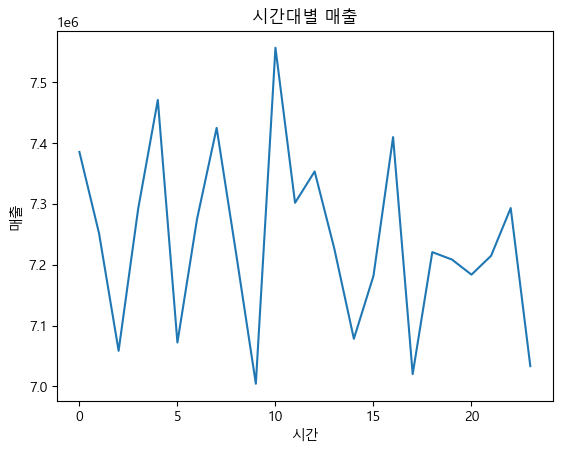

In [8]:
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

hourly_sales.plot(kind='line')
plt.title("시간대별 매출")
plt.xlabel("시간")
plt.ylabel("매출")
plt.show()